Linear Regression Performance
MAE: 512.9773048548959
RMSE: 514.9444078949971
R2: -184.47963538363118

Random Forest Performance
MAE: 159.4307142857143
RMSE: 168.84395059809344
R2: -18.940982456246786

Random Forest Selected as Final Model


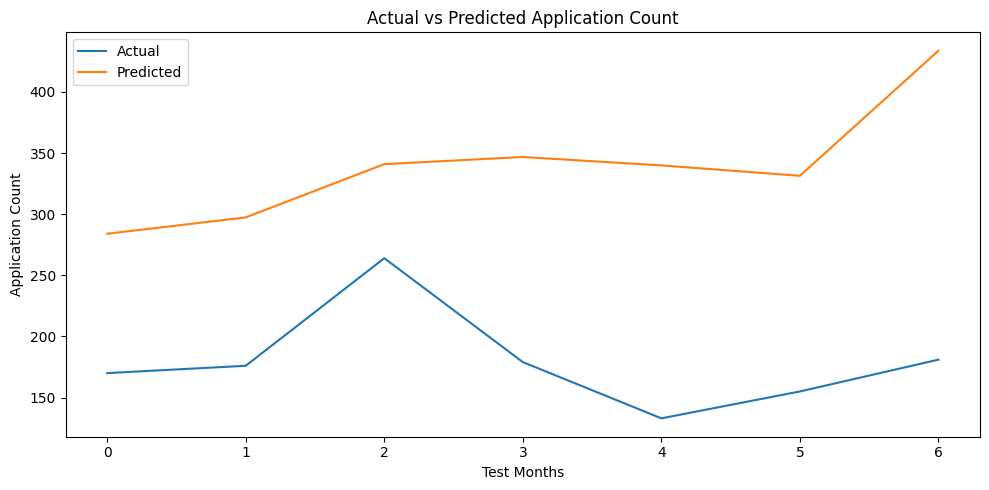


Future 6-Month Forecast:
Month 1 Forecast: 1165.47
Month 2 Forecast: 1003.5
Month 3 Forecast: 440.82
Month 4 Forecast: 259.04
Month 5 Forecast: 276.55
Month 6 Forecast: 284.0


In [1]:
# ============================================================
# SLU Opportunity Application Forecasting
# Week 3 – Predictive Modeling
# Author: Zakhir Shaikh
# ============================================================

# ----------------------------
# 1. Import Required Libraries
# ----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ----------------------------
# 2. Load Cleaned Dataset
# ----------------------------

df = pd.read_excel("cleaned_slu_data.xlsx")

# Convert Apply Date to datetime
df['Apply Date'] = pd.to_datetime(df['Apply Date'])


# ----------------------------
# 3. Monthly Aggregation
# ----------------------------

# Create Year-Month column
df['YearMonth'] = df['Apply Date'].dt.to_period('M')

# Count applications per month
monthly_data = df.groupby('YearMonth').size().reset_index(name='Application_Count')

# Convert period to timestamp
monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()


# ----------------------------
# 4. Feature Engineering
# ----------------------------

# Create numerical time index
monthly_data['Time_Index'] = np.arange(len(monthly_data))

# Extract month and year
monthly_data['Month'] = monthly_data['YearMonth'].dt.month
monthly_data['Year'] = monthly_data['YearMonth'].dt.year


# ----------------------------
# 5. Train-Test Split (80-20)
# ----------------------------

X = monthly_data[['Time_Index', 'Month', 'Year']]
y = monthly_data['Application_Count']

split_index = int(len(monthly_data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


# ----------------------------
# 6. Linear Regression Model
# ----------------------------

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)


# ----------------------------
# 7. Random Forest Model
# ----------------------------

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


# ----------------------------
# 8. Model Selection
# ----------------------------

if rmse_rf < rmse_lr:
    final_model = rf
    print("\nRandom Forest Selected as Final Model")
else:
    final_model = lr
    print("\nLinear Regression Selected as Final Model")


# ----------------------------
# 9. Actual vs Predicted Plot
# ----------------------------

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_rf, label='Predicted')
plt.title("Actual vs Predicted Application Count")
plt.xlabel("Test Months")
plt.ylabel("Application Count")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 10. Forecast Next 6 Months
# ----------------------------

future_periods = 6

last_index = monthly_data['Time_Index'].iloc[-1]
last_month = monthly_data['Month'].iloc[-1]
last_year = monthly_data['Year'].iloc[-1]

future_data = pd.DataFrame({
    'Time_Index': np.arange(last_index + 1, last_index + 1 + future_periods)
})

future_data['Month'] = [(last_month + i - 1) % 12 + 1 for i in range(1, future_periods + 1)]
future_data['Year'] = last_year

future_predictions = final_model.predict(future_data)

print("\nFuture 6-Month Forecast:")
for i, pred in enumerate(future_predictions, 1):
    print(f"Month {i} Forecast:", round(pred, 2))